### Handwritten Digits Recognition

In [12]:
#The objective of this project is to build a handwritten digit recognition system using the MNIST dataset,
#which contains images of digits from 0 to 9.

#Installing Tensorflow

In [14]:
#pip install scikit-learn tensorflow

## Importing Libraries:

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## Reading Dataset:

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

## Exploratory Data Analysis:

In [21]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [22]:
y_train[0]

5

In [23]:
#Assuming y contains labels of the MNIST dataset
#univariate
sns.countplot(x=y)
plt.title("Distribution of Digit Labels")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.show()

NameError: name 'y' is not defined

In [53]:
# Assuming X is the MNIST dataset with shape (n_samples, 28*28)
#bivariate
import pandas as pd

pixel1 = X[:, 0]  # Top-left corner pixel
pixel2 = X[:, -1]  # Bottom-right corner pixel

plt.scatter(pixel1, pixel2, alpha=0.5)
plt.title("Pixel Intensity Comparison")
plt.xlabel("Top-left Pixel Intensity")
plt.ylabel("Bottom-right Pixel Intensity")
plt.show()

NameError: name 'X' is not defined

Text(0.5, 1.0, '5')

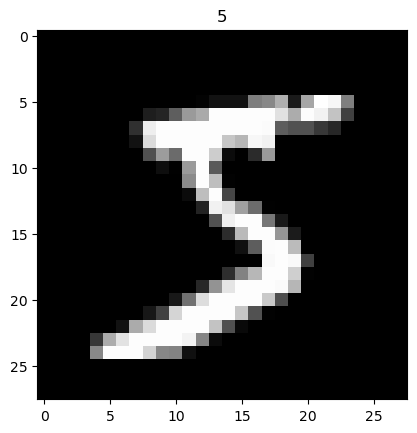

In [55]:
plt.imshow(X_train[0],cmap=plt.gray())
plt.title(y_train[0])

In [57]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
#Training dataset= 60000
#Testing dataset= 10000

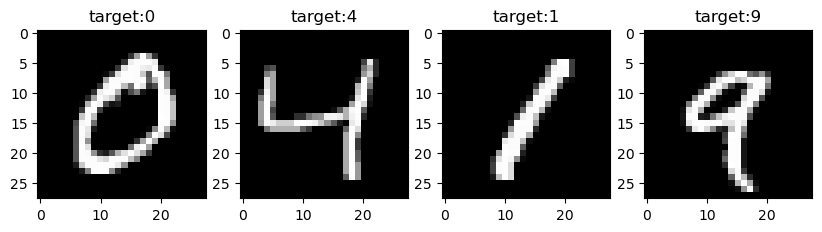

In [59]:
#sample image visualization:
plt.figure(figsize=(10,8))
for i in range(1,5):
    plt.subplot(1,4,i)
    plt.imshow(X_train[i],cmap=plt.gray())
    plt.title(f'target:{y_train[i]}')

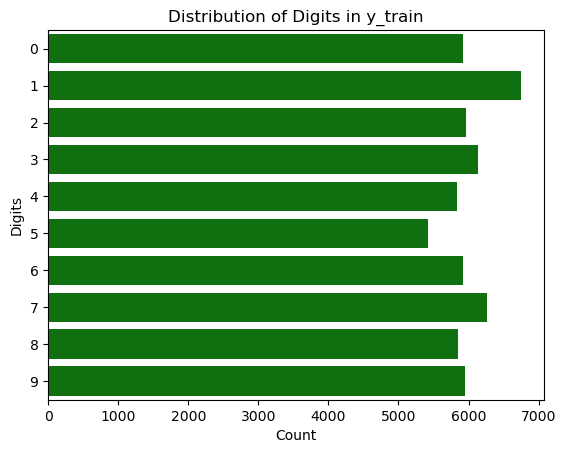

In [61]:
# To count no.of samples for each digits:
y_train_series=pd.Series(y_train)
sns.countplot(y=y_train_series, color="green")  
# Add title and label to the y-axis
plt.title("Distribution of Digits in y_train")
plt.ylabel("Digits")  # Labeling the y-axis as "Digits"
plt.xlabel("Count") 
plt.show()

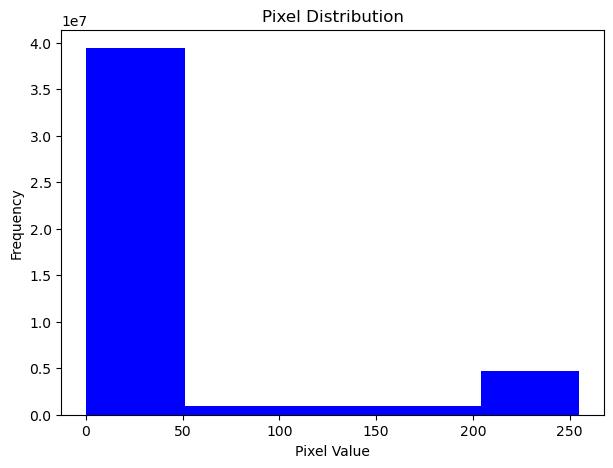

In [63]:
# to understand the distribution:
plt.figure(figsize=(7,5))
plt.hist(X_train.flatten(), bins=5, color='blue')
plt.title("Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

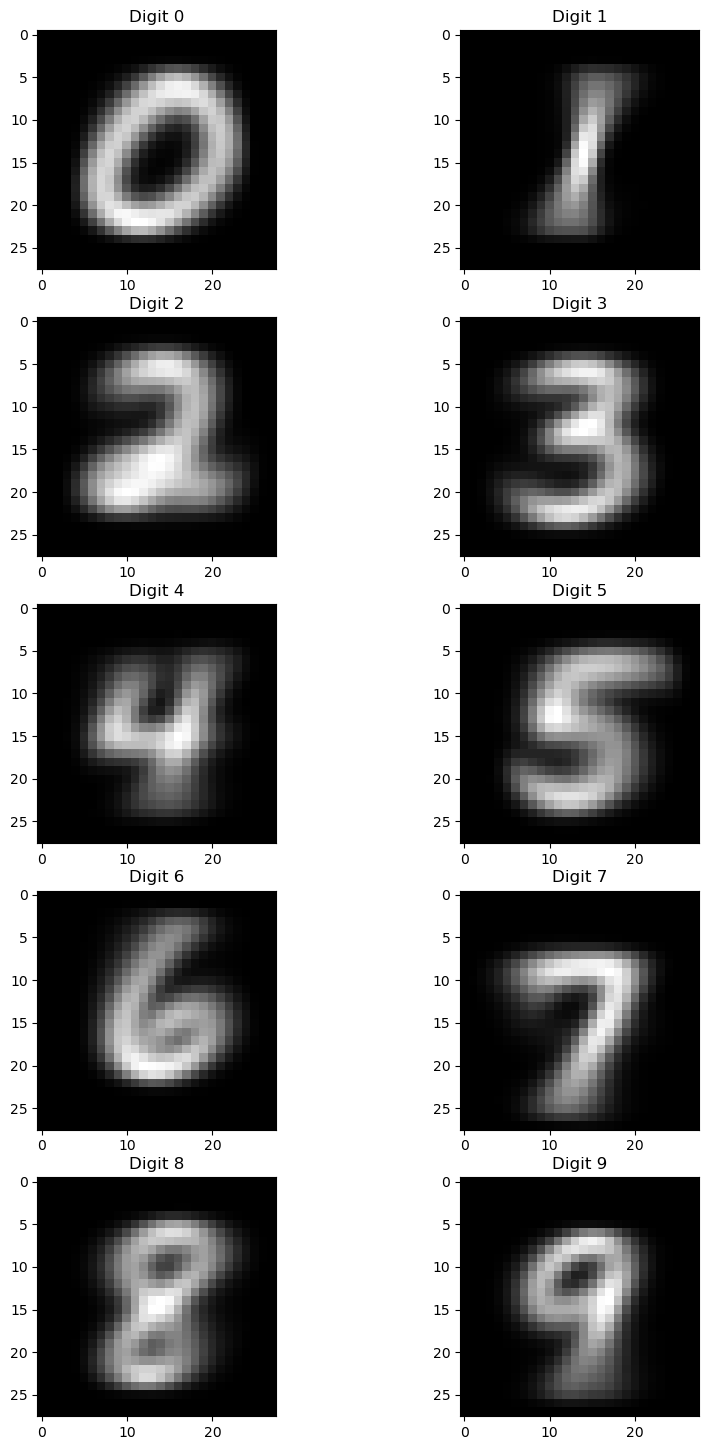

In [67]:
# mean image of each classes:
mean_images = [X_train[y_train == i].mean(axis=0).reshape(28,28) for i in range(10)]
plt.figure(figsize=(10,18))
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(mean_images[i], cmap='gray')
    plt.title(f"Digit {i}")
plt.show()

In [65]:
#reshape to 2d array x_train and x_test
X_train=X_train.reshape(60000,784)
X_test=X_test.reshape(10000,784)

In [69]:
#one hot encoder applied for y_train and y test
y_train_ohe=to_categorical(y_train)
y_test_ohe=to_categorical(y_test)

In [71]:
#In the case of MNIST, where the goal is to classify images into one of 10 possible digit categories (0–9),
#one-hot encoding ensures the model can learn to correctly distinguish between all possible digit classes.

In [73]:
#Checking shape after reshaping
print(X_train.shape)
print(y_train_ohe.shape)
print(X_test.shape)
print(y_test_ohe.shape)

(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


In [75]:
print(y_train_ohe[:5])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [77]:
print(y_train[:5])

[5 0 4 1 9]


## Normalization:

In [79]:
X_train=X_train/255
X_test=X_test/255

## Model Building:

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import *

In [84]:
model=Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(74,activation='relu')) #hidden layer
model.add(Dense(10,activation='softmax'))#output layer

In [86]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

## Model fitting:

In [89]:
model.fit(x=X_train,y=y_train_ohe,validation_data=(X_test,y_test_ohe),epochs=20,batch_size=100)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8247 - loss: 0.6310 - val_accuracy: 0.9343 - val_loss: 0.2245
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9399 - loss: 0.2048 - val_accuracy: 0.9524 - val_loss: 0.1593
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9573 - loss: 0.1531 - val_accuracy: 0.9600 - val_loss: 0.1350
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9671 - loss: 0.1160 - val_accuracy: 0.9634 - val_loss: 0.1226
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.0965 - val_accuracy: 0.9704 - val_loss: 0.0996
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0789 - val_accuracy: 0.9715 - val_loss: 0.0936
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9819 - loss: 0.0647 - val_accuracy: 0.9725 - val_loss: 0.0868
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9824 - loss: 0.0602 - val_accuracy: 0.

In [91]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 74)                  │          58,090 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             750 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 176,522 (689.54 KB)

 Trainable params: 58,840 (229.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 117,682 (459.70 KB)

In [93]:
pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [95]:
pred_class=np.argmax(pred,axis=1)

## Support Vector Machine:

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import *


In [100]:
#model training throgh SVM

In [105]:
model=SVC()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [103]:
##svm Classification

In [108]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
param_grid={
    'C':[0.1,1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['linear','rbf','poly']
}
grid=GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(X_train,y_train)
print(" Best Parametrs ",grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 2.6min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 2.6min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 2.6min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 2.5min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 2.6min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=64.7min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=94.2min


In [ ]:
best_params={'c':100,'gamma':0.1,'kernel':'linear'}
grid=SVC(**best_params)
grid.fit(xdata_train,y_train)
y_pred=grid.predict(x_test)
print(accuracy_score(y_test,y_pred))

## K-Nearest Neighbour:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
#Model training through Kneighbors

In [ ]:
# K-Nearest Neighbour
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

In [ ]:
y_pred_knn = knn_model.predict(X_test)


In [ ]:
#kneighborsclassifier

In [ ]:
print(classification_report(y_test,y_pred_knn))

In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

## Model Performance and Result:

In [ ]:
cm=confusion_matrix(y_test,pred_class)
cm

In [ ]:
#heatmap
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,pred_class))

In [ ]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test,y_pred))